# Introduction

AdEase is an ads and marketing–based company that helps businesses elicit maximum user clicks at minimal cost. It provides a robust ad infrastructure that enables organizations to promote their products and services easily, effectively, and economically.

At the core of AdEase’s platform is the seamless interplay of three AI-driven modules:

- Design – crafting optimized ad creatives,

- Dispense – delivering ads to the right platforms and audiences, and

- Decipher – analyzing performance data to continuously improve ad outcomes.

Together, these modules form an end-to-end, three-step digital advertising solution for businesses across domains.

# Problem Context

As a Data Scientist at AdEase, your task is to analyze page-level view data for various Wikipedia pages and build forecasting models that can help predict future traffic trends. These predictions are crucial for optimizing ad placements, ensuring that client advertisements are shown on high-traffic pages at the right time, thereby maximizing return on investment.

The dataset provided contains:

- Daily page view counts for approximately 145,000 Wikipedia pages

- Observations spanning 550 consecutive days

- Pages belonging to different languages and regions, reflecting a diverse global audience

Since AdEase’s clients operate across multiple geographies, understanding language-wise and region-wise traffic patterns is essential to predict how advertisements will perform on different types of pages.

# Objective of Analysis

The primary objectives of this analysis are:

To explore and understand the historical page view behavior of Wikipedia pages.

1. To identify trends, seasonality, and patterns across different languages.

2. To build time-series forecasting models that accurately predict future page views.

3. To use these forecasts to provide actionable recommendations for optimizing ad placement strategies for AdEase’s clients.

This analysis will enable AdEase to make data-driven decisions, improve ad delivery efficiency, and ultimately help businesses achieve better visibility and engagement at lower costs.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    r2_score,
    mean_absolute_percentage_error as mape
)
from statsmodels.tsa.arima_model import ARIMA
from sklearn.preprocessing import MinMaxScaler

## Data Loading

In [1]:
!gdown 15Pbb2o8Ee3e4x3NHSJBCS98v4TH2_1R3

Downloading...
From (original): https://drive.google.com/uc?id=15Pbb2o8Ee3e4x3NHSJBCS98v4TH2_1R3
From (redirected): https://drive.google.com/uc?id=15Pbb2o8Ee3e4x3NHSJBCS98v4TH2_1R3&confirm=t&uuid=98872b12-62e3-48a8-ba0f-9803fd072fca
To: /Users/nagarjuncn/Documents/Projects/Case Studies/train_1.csv
100%|████████████████████████████████████████| 278M/278M [01:41<00:00, 2.75MB/s]


In [3]:
df = pd.read_csv('train_1.csv')
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [4]:
!gdown 1wHfj9sei3kP3LZ3YWPphR5EGYM_pWKNy

Downloading...
From: https://drive.google.com/uc?id=1wHfj9sei3kP3LZ3YWPphR5EGYM_pWKNy
To: /Users/nagarjuncn/Documents/Projects/Case Studies/Exog_Campaign_eng
100%|██████████████████████████████████████| 1.10k/1.10k [00:00<00:00, 2.11MB/s]


In [5]:
exog_en = pd.read_csv('Exog_Campaign_eng')
exog_en.head()

,Exog
0,0
1,0
2,0
3,0
4,0


In [6]:
def dataset_summary(df):
    print("DATASET INFORMATION")
    print("-" * 50)
    df.info()

    print("\nDATASET SHAPE")
    print("-" * 50)
    print(df.shape)

    print("\nMISSING VALUES PER COLUMN")
    print("-" * 50)
    print(df.isna().sum())

    print("\nUNIQUE VALUES PER COLUMN")
    print("-" * 50)
    print(df.nunique())

    print("\nDUPLICATE ROWS")
    print("-" * 50)
    print(df.duplicated().value_counts())

dataset_summary(df)

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB

DATASET SHAPE
--------------------------------------------------
(145063, 551)

MISSING VALUES PER COLUMN
--------------------------------------------------
Page              0
2015-07-01    20740
2015-07-02    20816
2015-07-03    20544
2015-07-04    20654
              ...  
2016-12-27     3701
2016-12-28     3822
2016-12-29     3826
2016-12-30     3635
2016-12-31     3465
Length: 551, dtype: int64

UNIQUE VALUES PER COLUMN
--------------------------------------------------
Page          145063
2015-07-01      6898
2015-07-02      6823
2015-07-03      6707
2015-07-04      6995
               ...  
2016-12-27      8938
2016-12-28      8819
2016-12-29      8761
2016-12-30      8733
2016-12-31      8826
Length: 551, dtype: int64

DUPLICATE ROWS


In [7]:
df.describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,1.247210e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
mean,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,1.189651e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,7.214536e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,1.130000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,5.450000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02
max,2.038124e+07,2.075219e+07,1.957397e+07,2.043964e+07,2.077211e+07,2.254467e+07,2.121089e+07,1.910791e+07,1.999385e+07,2.020182e+07,...,2.420108e+07,2.253925e+07,2.505662e+07,2.586575e+07,2.834288e+07,2.691699e+07,2.702505e+07,2.607382e+07,2.436397e+07,2.614954e+07


In [8]:
df.describe(include = 'object')

,Page
count,145063
unique,145063
top,2NE1_zh.wikipedia.org_all-access_spider
freq,1


**Insights:**
- There are **145063** entries with 551 columns, i.e. 145063 wikipedia pages with views for 550 days
- There are null/missing values in each of the dates
- There are no **duplicates**
- There are **145063** unique wikipedia pages

In [9]:
dataset_summary(exog_en)

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB

DATASET SHAPE
--------------------------------------------------
(550, 1)

MISSING VALUES PER COLUMN
--------------------------------------------------
Exog    0
dtype: int64

UNIQUE VALUES PER COLUMN
--------------------------------------------------
Exog    2
dtype: int64

DUPLICATE ROWS
--------------------------------------------------
True     548
False      2
Name: count, dtype: int64


**Insights**
- There are **550** entries corresponding to 550 days in the previous dataset
- There are **no** null/missing values
- There are **2** unique values - 1 ans 0

# Exploratory Data Analysis

## Analysis Data Columns

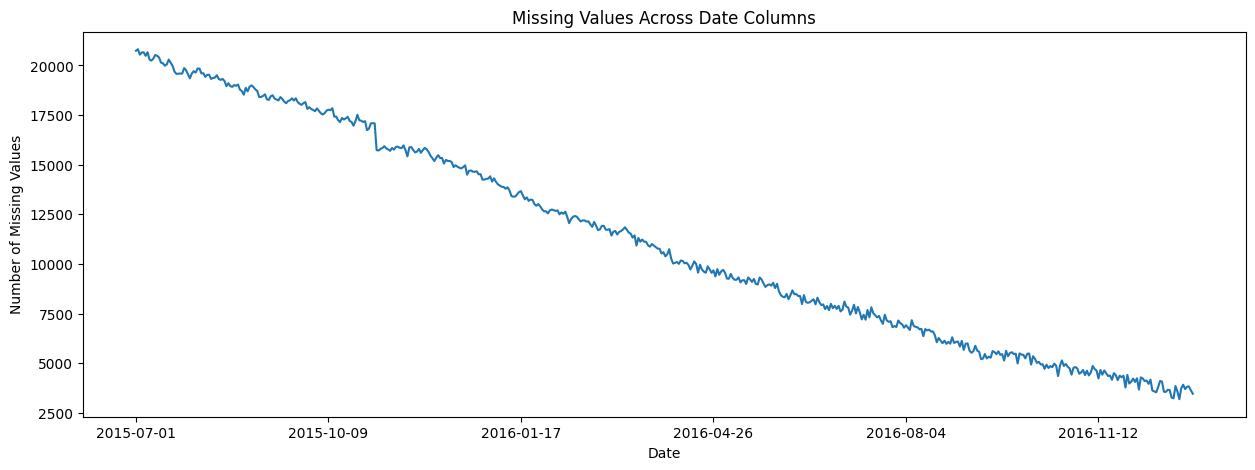

In [10]:
date_cols = df.columns[1:]

missing_counts = df[date_cols].isna().sum()

plt.figure(figsize=(15, 5))
missing_counts.plot()
plt.title("Missing Values Across Date Columns")
plt.xlabel("Date")
plt.ylabel("Number of Missing Values")
plt.show()

In [12]:
df[date_cols] = df[date_cols].fillna(0)

In [13]:
df.isna().sum()

Page          0
2015-07-01    0
2015-07-02    0
2015-07-03    0
2015-07-04    0
             ..
2016-12-27    0
2016-12-28    0
2016-12-29    0
2016-12-30    0
2016-12-31    0
Length: 551, dtype: int64

# Extracting Information from Page Column

In [14]:
df['Page'].sample(10)

57243          だがしかし_ja.wikipedia.org_mobile-web_all-agents
117011    Newton_(Einheit)_de.wikipedia.org_mobile-web_a...
11588     Manny_Pacquiao_en.wikipedia.org_desktop_all-ag...
94034     Billie_Lourd_es.wikipedia.org_mobile-web_all-a...
43372     Installation/de_www.mediawiki.org_desktop_all-...
41609     Eddie_Murphy_en.wikipedia.org_all-access_all-a...
91379     Octavio_Paz_es.wikipedia.org_all-access_all-ag...
100112    Одержимость_(фильм,_2014)_ru.wikipedia.org_all...
78221     File:Chris_Evans_2010.jpg_commons.wikimedia.or...
54245     Tom_Dumoulin_fr.wikipedia.org_mobile-web_all-a...
Name: Page, dtype: object

**Insights**
	The sample shows representation from multiple languages (Spanish, Japanese, Chinese, French, Russian, German), indicating that the dataset is multilingual.
- Both desktop and mobile-web access types appear, suggesting the data captures multiple device usage patterns.
- 	All entries are tagged as all-agents, implying the dataset primarily contains human-generated traffic rather than bot traffic.
- 	Page topics vary (biographies, pop culture, literature), indicating content diversity.

### Extracting Page Name

In [15]:
def extract_page_name(page):
    match = re.search(r'^(.*)_([a-z]{2})\.wikipedia\.org_', page)
    return match.group(1) if match else 'unknown'

df['Page_Name'] = df['Page'].apply(extract_page_name)
    


/var/folders/9f/84szqpc904bc4pmtfx4559d80000gn/T/ipykernel_99478/536359589.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Page_Name'] = df['Page'].apply(extract_page_name)


### Extracting Languages

In [16]:
def extract_language(page):
    match = re.search(r'_(\w{2})\.wikipedia\.org_', page)
    return match.group(1) if match else 'un'

df['language'] = df['Page'].apply(extract_language)
print(df['language'].unique())

['zh' 'fr' 'en' 'un' 'ru' 'de' 'ja' 'es']


/var/folders/9f/84szqpc904bc4pmtfx4559d80000gn/T/ipykernel_99478/3272923999.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['language'] = df['Page'].apply(extract_language)


<Axes: title={'center': 'Language Distribution'}, xlabel='language'>

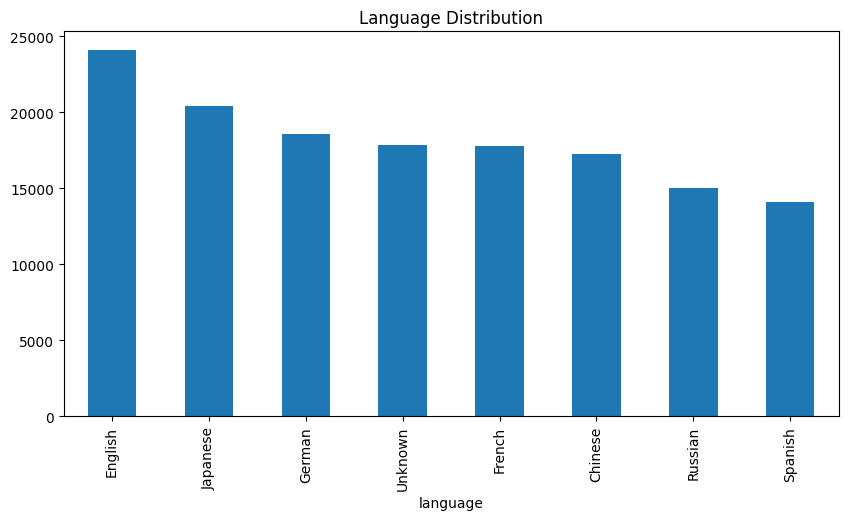

In [17]:
lang_name_mapping={'zh':'Chinese', 'fr':'French', 'en':'English',
                   'un':'Unknown', 'ru':'Russian', 'de':'German',
                   'ja':'Japanese', 'es':'Spanish'}

df['language'] = df['language'].map(lang_name_mapping)
df['language'].value_counts().plot(kind='bar', figsize=(10,5), title='Language Distribution')

In [18]:
print("% of pages in different languages")
round(df['language'].value_counts(normalize=True)*100,2)

% of pages in different languages


language
English     16.62
Japanese    14.08
German      12.79
Unknown     12.31
French      12.27
Chinese     11.88
Russian     10.36
Spanish      9.70
Name: proportion, dtype: float64

**Insights**
- English leads (16.62%), but it’s not dominant. Engagement is quite spread across languages.
- Japanese (14.08%) and German (12.79%) are strong secondary languages — together with English they already account for ~43%.
- “Unknown” is high (12.31%) — this is a red flag worth investigating (tracking, parsing, or classification issue).
-	French (12.27%) and Chinese (11.88%) are almost equal, indicating comparable audience interest.
-	Russian (10.36%) and Spanish (9.70%) are slightly lower but still significant.

### Extracting Access Type

In [19]:
df['access_type'] = df['Page'].str.extract(
    r'\.wikipedia\.org_([^_]+)_',
    expand=False
)

print(df['access_type'].unique())

['all-access' 'desktop' nan 'mobile-web']


/var/folders/9f/84szqpc904bc4pmtfx4559d80000gn/T/ipykernel_99478/2129084854.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['access_type'] = df['Page'].str.extract(


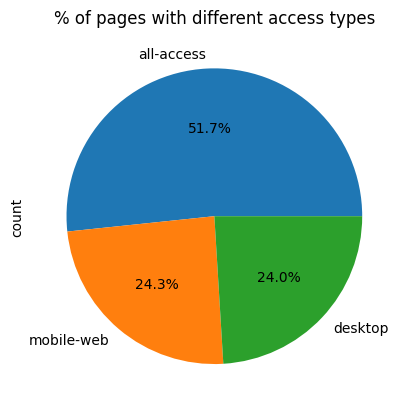

In [20]:
df['access_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different access types')
plt.show()

**Insights:**
-	All-access dominates (~52%), indicating many pages are device-agnostic.
-	Mobile-web and desktop are evenly split (~24% each), showing balanced device usage.
-	Implication: use all-access pages for broad reach, and apply device-specific strategies for mobile and desktop.

### Extracting Access Origin


In [21]:
df['access_origin'] = df['Page'].str.extract(r'_([^_]+)$', expand=False)
print(df['access_origin'].unique())

['spider' 'all-agents']


/var/folders/9f/84szqpc904bc4pmtfx4559d80000gn/T/ipykernel_99478/3668534457.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['access_origin'] = df['Page'].str.extract(r'_([^_]+)$', expand=False)


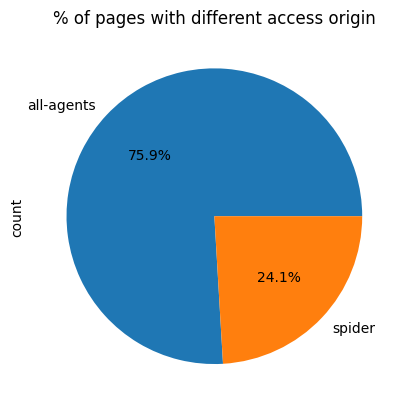

In [22]:
df['access_origin'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different access origin')
plt.show()

**Insights:**


- All-agents dominate (~76%), indicating most page views are from human users.
-	Spiders account for ~24%, representing bot/crawler traffic.
-	Implication: ad performance analysis and forecasting should focus on all-agents traffic, while spider traffic should be excluded or modeled separately.

In [23]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Page_Name,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,Chinese,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,Chinese,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,Chinese,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,Chinese,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,Chinese,all-access,spider


## Aggregating and Pivoting

In [27]:
df_agg = df.drop(columns = ['Page', 'Page_Name', 'access_type','access_origin']).groupby('language').mean().T.reset_index()
df_agg['index'] = pd.to_datetime(df_agg['index'])
df_agg = df_agg.set_index('index')
df_agg.head()

language,Chinese,English,French,German,Japanese,Russian,Spanish,Unknown
index,,,,,,,,
2015-07-01,240.582042,3513.862203,475.150994,714.968405,580.647056,629.999601,1085.972919,83.479922
2015-07-02,240.941958,3502.511407,478.202000,705.229741,666.672801,640.902876,1037.814557,87.471857
2015-07-03,239.344071,3325.357889,459.837659,676.877231,602.289805,594.026295,954.412680,82.680538
2015-07-04,241.653491,3462.054256,491.508932,621.145145,756.509177,558.728132,896.050750,70.572557
2015-07-05,257.779674,3575.520035,482.557746,722.076185,725.720914,595.029157,974.508210,78.214562


## Time Series plots for all the languages

<Axes: title={'center': 'Average Page Views by Language Over Time'}, xlabel='index'>

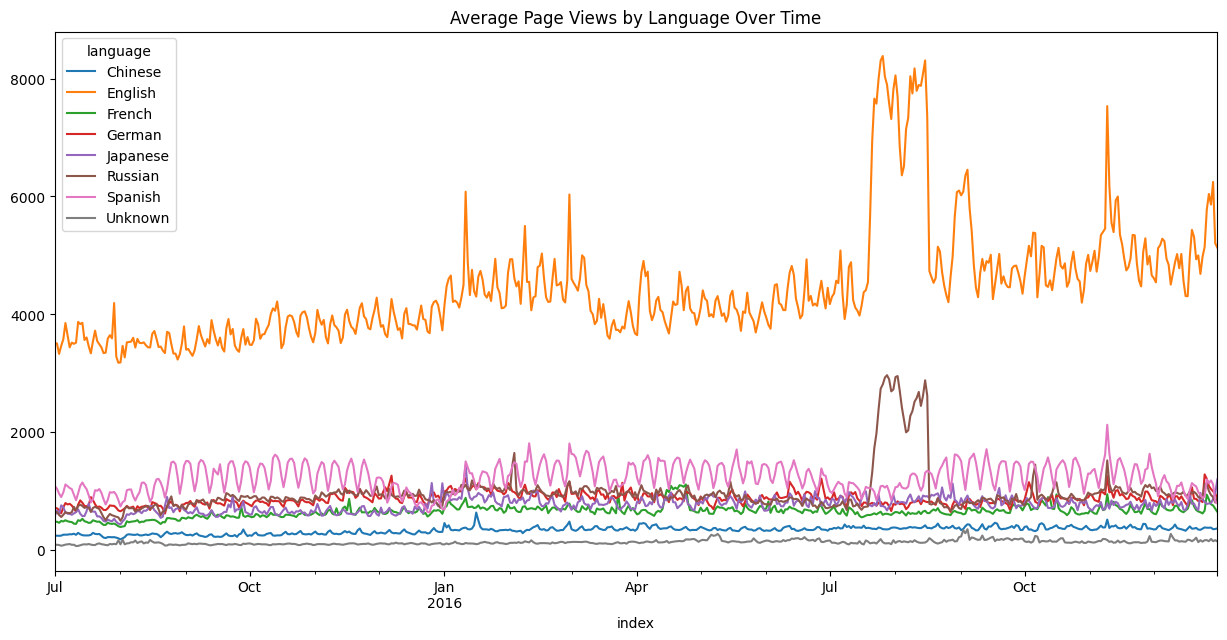

In [28]:
df_agg.plot(figsize=(15,7), title='Average Page Views by Language Over Time')

**Insights:**
- 	English clearly dominates average page views and shows high volatility with sharp spikes → likely driven by events/campaigns.
- Japanese and Spanish form the second tier, showing strong weekly seasonality and moderate volatility.
- German, French, and Russian are more stable, with smoother trends and fewer extreme spikes.
- Chinese and Unknown have lower average views and relatively flat behavior.
-	Most languages show recurring seasonal patterns, indicating non-stationarity.



# Stationarity, Detrending, ACF, and PACF

## Stationarity Test

**Using Augmented Dickey-Fuller test to check for stationarity**
- H0: The series is not stationary
- H1: The series is stationary

In [29]:
def adfuller_test(series, alpha=0.05):
    result = sm.tsa.stattools.adfuller(series.dropna())
    p_value = result[1]
    
    if p_value < alpha:
        print(f"Stationary (p-value = {p_value:.4f})")
    else:
        print(f"Non-stationary (p-value = {p_value:.4f})")

In [30]:
for lang in df_agg.columns:
    print(f"ADF Test for {lang}:")
    adfuller_test(df_agg[lang])
    print()

ADF Test for Chinese:
Non-stationary (p-value = 0.4474)

ADF Test for English:
Non-stationary (p-value = 0.1895)

ADF Test for French:
Non-stationary (p-value = 0.0515)

ADF Test for German:
Non-stationary (p-value = 0.1410)

ADF Test for Japanese:
Non-stationary (p-value = 0.1026)

ADF Test for Russian:
Stationary (p-value = 0.0019)

ADF Test for Spanish:
Stationary (p-value = 0.0336)

ADF Test for Unknown:
Stationary (p-value = 0.0163)



**Insight:**
- Based on the Augmented Dickey-Fuller test, the time series corresponding to **Russian** and **Spanish** language page visits are **stationary**
- The time series corresponding to **Chinese, English, French, German** and **Japanese** language page visits are **not stationary**

**Let us examine the English language time series along with its corresponding exogenous campaign indicator**

In [31]:
ts_english = df_agg['English']

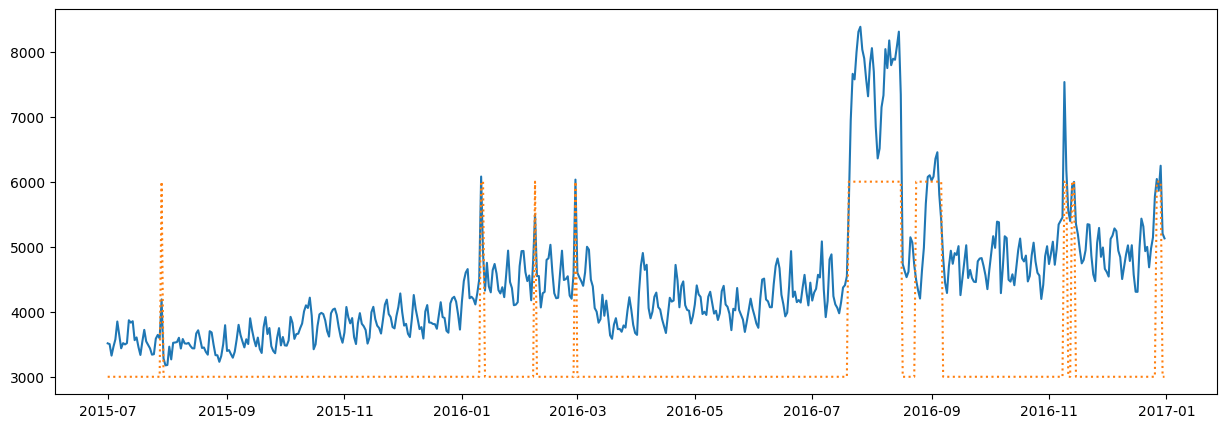

In [32]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ts_english.index, ts_english)
ax.plot(ts_english.index, (exog_en+1)*3000, ':')
plt.show()

**Insights**:
-	Clear alignment between campaign periods and sharp spikes in English page views.
-	Campaign days coincide with sudden level shifts, not just small fluctuations.
-	Outside campaign periods, the series shows regular seasonality and moderate volatility.
-	Confirms that external events significantly influence English traffic.

## Detrending and Deseasoning

<Axes: title={'center': 'First Difference of English Page Views'}, xlabel='index'>

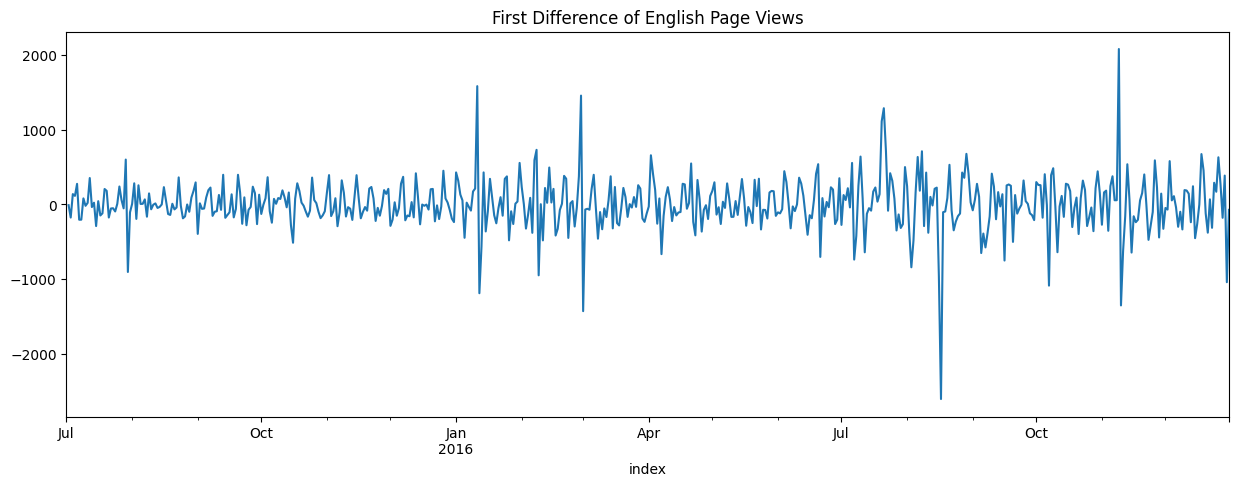

In [33]:
ts_english.diff(1).plot(figsize=(15,5), title='First Difference of English Page Views')

In [34]:
adfuller_test(ts_english.diff(1).dropna())

Stationary (p-value = 0.0000)


The time series became stationary by just doing first-order differencing, hence **d=1**\
Let's now look at the seasonality

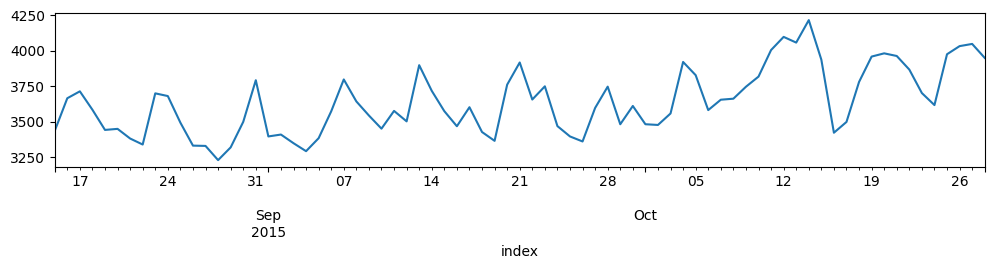

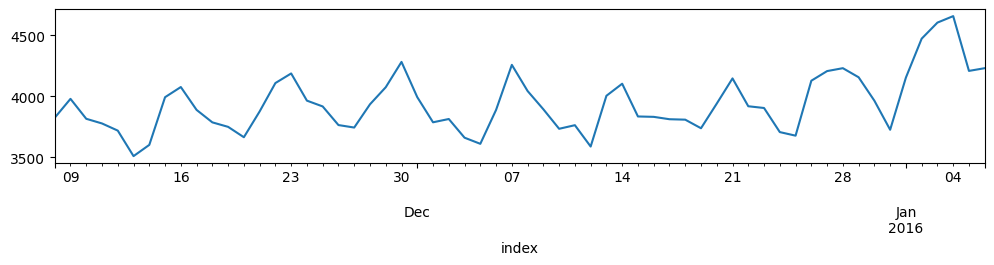

In [35]:
ts_english[45:120].plot(figsize=(12,2))
plt.show()
ts_english[130:190].plot(figsize=(12,2))
plt.show()

**Insights:**
- Observing the above two plots, we can conclude that there is a **seasonality** of **7 days**. So **s=7**
- The peaks and troughs repeat every 7 days

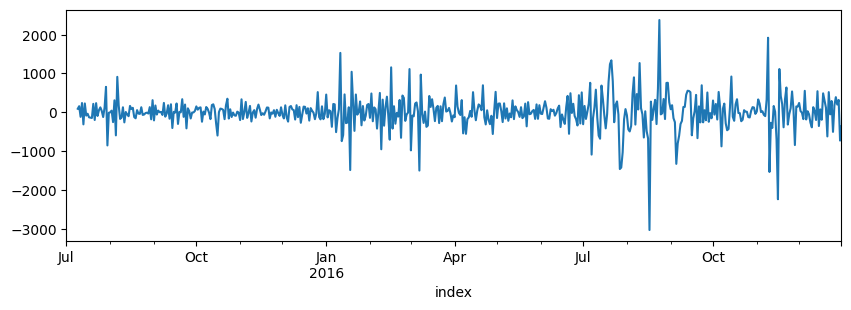

In [36]:
ts_english.diff(1).diff(7).plot(figsize=(10,3))
plt.show()

In [37]:
adfuller_test(ts_english.diff(1).diff(7).dropna())

Stationary (p-value = 0.0000)


After **removing** the **trend**(and if required, **seasonality**) manually, the Augmented Dickey-Fuller test says that the **time series is stationary**

## Auto Decomposition

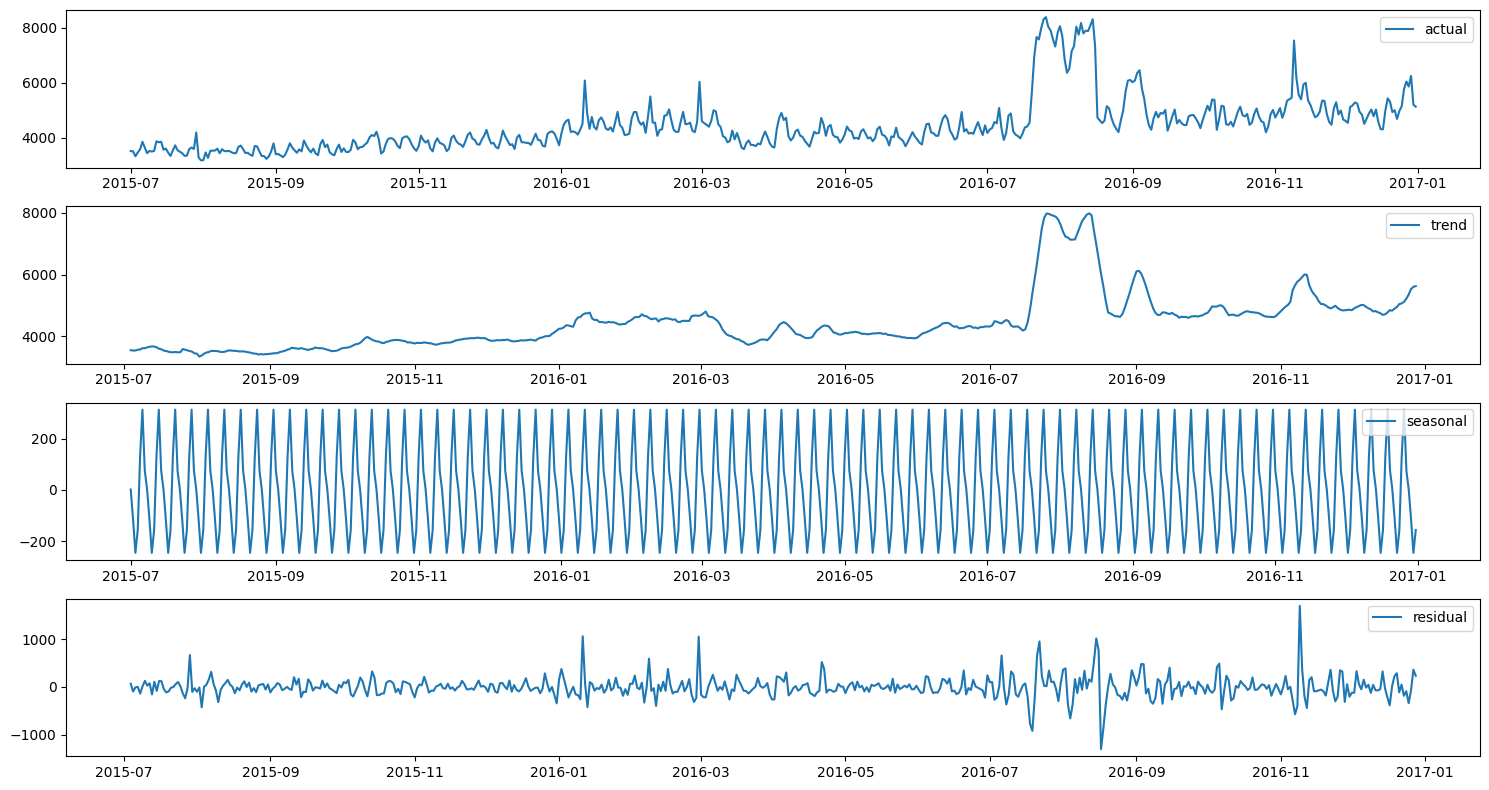

In [38]:
#Using statsmodel to decompose the time series
decom = seasonal_decompose(ts_english)
ts_english_trend = decom.trend
ts_english_seas = decom.seasonal
ts_english_res = decom.resid
plt.figure(figsize=(15,8))
plt.subplot(411)
plt.plot(ts_english, label='actual')
plt.legend()
plt.subplot(412)
plt.plot(ts_english_trend, label='trend')
plt.legend()
plt.subplot(413)
plt.plot(ts_english_seas, label='seasonal')
plt.legend()
plt.subplot(414)
plt.plot(ts_english_res, label='residual')
plt.legend()
plt.tight_layout()
plt.show()

## ACF and PACF Plots

- The **ACF (Autocorrelation Function)** measures the correlation of a time series with its own past values at different lags.  
- The **PACF (Partial Autocorrelation Function)** measures the correlation at a given lag after removing the influence of all shorter lags.  
- The **PACF plot is used to identify the order of an AR model**, where a sharp cut-off indicates the number of autoregressive terms.  
- The **ACF plot is used to identify the order of an MA model**, where significant spikes indicate the number of moving average terms.  

**Note:** ACF and PACF should be computed on a **stationary time series** for meaningful interpretation.

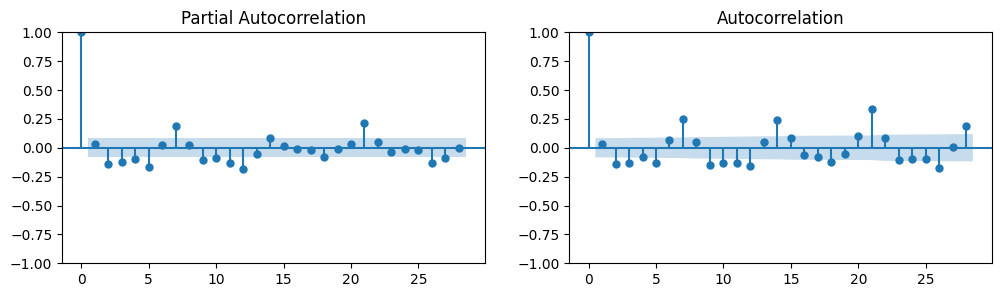

In [39]:
fig, axs = plt.subplots(1,2, figsize=(12, 3))
plot_pacf(ax=axs[0], x=ts_english.diff(1).dropna())
plot_acf(ax=axs[1], x=ts_english.diff(1).dropna())
plt.show()

# Model Building and Evaluation

In [41]:
def performance(actual, predicted, verbose=True):
    mae_val = mae(actual, predicted)
    rmse_val = mse(actual, predicted, squared=False)
    mape_val = mape(actual, predicted)

    if verbose:
        print(f"MAE  : {mae_val:.3f}")
        print(f"RMSE : {rmse_val:.3f}")
        print(f"MAPE : {mape_val:.3f}")

    return mae_val, rmse_val, mape_val

## ARIMA Model

In [42]:
TS = ts_english.copy(deep=True)

In [48]:
import numpy as np
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape

def performance(actual, predicted, print_metrics=True):
    MAE = round(mae(actual, predicted), 3)
    RMSE = round(np.sqrt(mse(actual, predicted)), 3)
    MAPE = round(mape(actual, predicted), 3)

    if print_metrics:
        print('MAE  :', MAE)
        print('RMSE :', RMSE)
        print('MAPE :', MAPE)

    return MAE, RMSE, MAPE

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


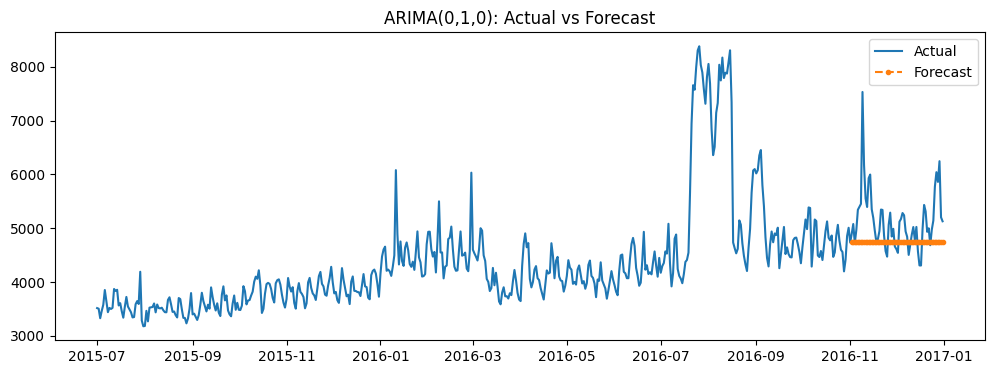

MAE  : 477.636
RMSE : 672.778
MAPE : 0.086


(477.636, np.float64(672.778), 0.086)

In [49]:
# Forecast horizon
n_forecast = 60

# Train–test split
train = TS.iloc[:-n_forecast]
test = TS.iloc[-n_forecast:]

# Build and fit ARIMA model
model = ARIMA(train, order=(0, 1, 0))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=n_forecast)

# Plot Actual vs Forecast
plt.figure(figsize=(12, 4))
plt.plot(TS, label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--', marker='.')
plt.legend(loc='upper right')
plt.title('ARIMA(0,1,0): Actual vs Forecast')
plt.show()

# Evaluate performance
performance(test.values, forecast.values, print_metrics=True)

## SARIMAX Model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid va

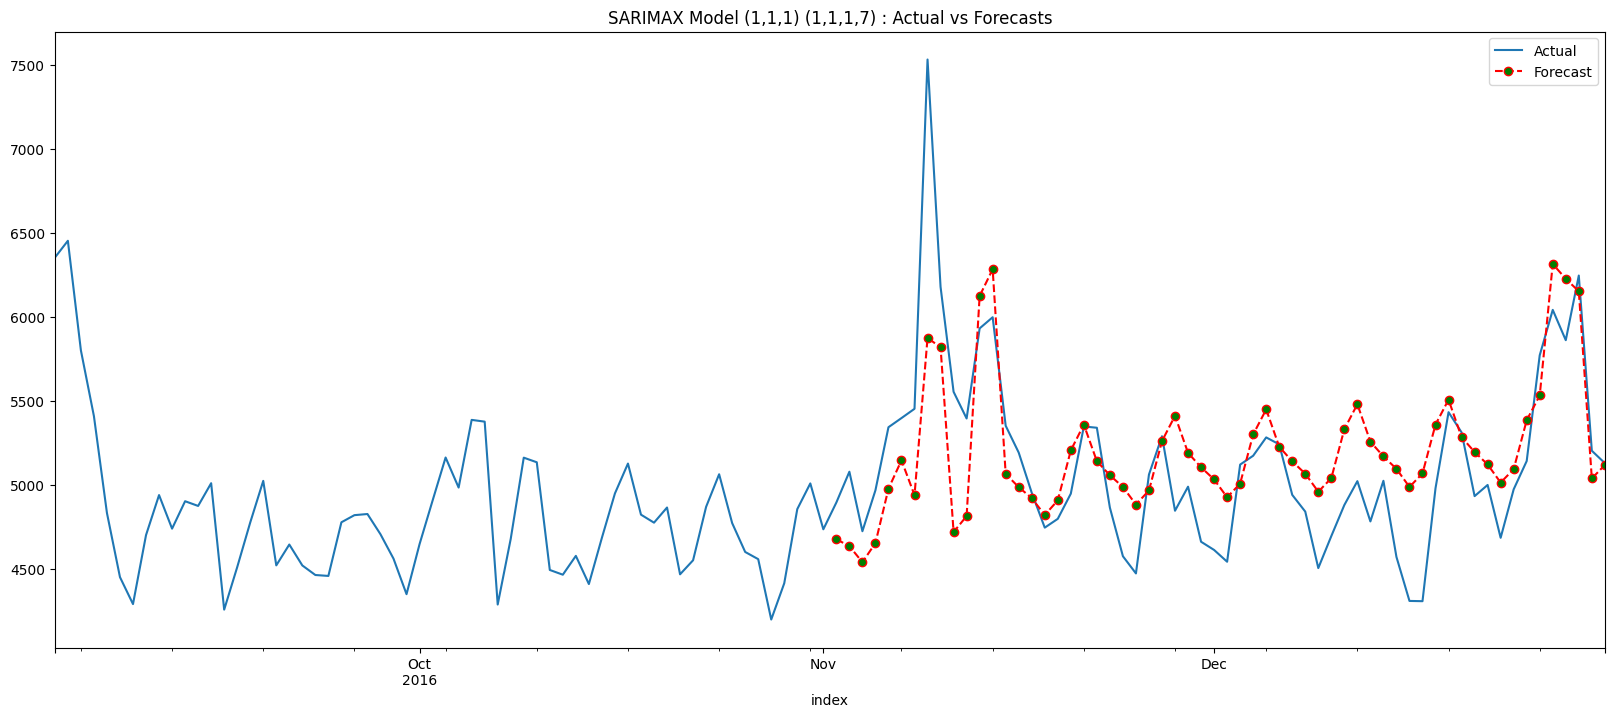

MAE  : 306.417
RMSE : 399.016
MAPE : 0.06


In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog = exog_en['Exog'].to_numpy()
p,d,q,P,D,Q,s = 1,1,1,1,1,1,7
n_forecast = 60
model = SARIMAX(TS[:-n_forecast], order =(p,d,q), seasonal_order=(P, D, Q, s), exog = exog[:-n_forecast], initialization='approximate_diffuse')
model_fit = model.fit()
#Creating forecast for last n-values
model_forecast = model_fit.forecast(n_forecast, dynamic = True, exog = pd.DataFrame(exog[-n_forecast:]))

plt.figure(figsize = (20,8))
TS[-120:].plot(label = 'Actual')
model_forecast[-120:].plot(label = 'Forecast', color = 'red', linestyle='dashed', marker='o',markerfacecolor='green')
plt.legend(loc="upper right")
plt.title(f'SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts')
plt.show()

(_,_,_) = performance(TS.values[-n_forecast:], model_forecast.values, print_metrics=True)

**Insights:** SARIMAX model is doing a significantly better job. We need to search for the right order values

In [51]:
def SARIMAX_search(
    TS, exog, n_forecast,
    p_list, d_list, q_list,
    P_list, D_list, Q_list, s_list
):
    results = []
    total = (len(p_list)*len(d_list)*len(q_list)*
             len(P_list)*len(D_list)*len(Q_list)*len(s_list))
    counter = 0

    # Train–test split
    y_train, y_test = TS[:-n_forecast], TS[-n_forecast:]
    exog = np.asarray(exog).reshape(-1, 1)
    exog_train, exog_test = exog[:-n_forecast], exog[-n_forecast:]

    for p in p_list:
        for d in d_list:
            for q in q_list:
                for P in P_list:
                    for D in D_list:
                        for Q in Q_list:
                            for s in s_list:
                                try:
                                    model = SARIMAX(
                                        y_train,
                                        order=(p,d,q),
                                        seasonal_order=(P,D,Q,s),
                                        exog=exog_train,
                                        initialization="approximate_diffuse"
                                    )
                                    fit = model.fit(disp=False)

                                    forecast = fit.get_forecast(
                                        steps=n_forecast,
                                        exog=exog_test
                                    ).predicted_mean

                                    _, rmse, mape_val = performance(
                                        y_test.values,
                                        forecast.values,
                                        print_metrics=False
                                    )

                                    counter += 1
                                    results.append({
                                        "serial": counter,
                                        "pdq": (p,d,q),
                                        "PDQs": (P,D,Q,s),
                                        "rmse": rmse,
                                        "mape": mape_val
                                    })

                                    print(f"Completed {counter}/{total}")

                                except Exception as e:
                                    continue

    return pd.DataFrame(results).sort_values("mape").reset_index(drop=True)

In [52]:
if 0:
    TS = ts_english.copy(deep=True)
    n_forecast = 60
    p_list = [0,1]
    d_list = [1]
    q_list = [0,1]
    P_list = [2,3]
    D_list = [1]
    Q_list = [2,3]
    s_list = [7]
    exog = exog_en['Exog'].to_numpy()
    perf_df = SARIMAX_search(TS, n_forecast, p_list, d_list, q_list, P_list, D_list, Q_list, s_list, exog)
    perf_df.sort_values(['mape', 'rmse'])

In [54]:
perf_df = SARIMAX_search(
    TS=TS,
    exog=exog_en['Exog'],
    n_forecast=60,
    p_list=[0,1,2],
    d_list=[1],
    q_list=[0,1,2],
    P_list=[0,1,2],
    D_list=[1],
    Q_list=[0,1,2,3],
    s_list=[7]
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

Completed 1/108
Completed 2/108
Completed 3/108


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid va

Completed 4/108
Completed 5/108
Completed 6/108


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python

Completed 106/108


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python

Completed 107/108
Completed 108/108


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
best_model = perf_df.sort_values('mape').iloc[0]

print("Best SARIMAX Parameters:")
print("p, d, q  :", best_model['pdq'])
print("P, D, Q, s :", best_model['PDQs'])
print("MAPE :", best_model['mape'])
print("RMSE :", best_model['rmse'])

Best SARIMAX Parameters:
p, d, q  : (2, 1, 2)
P, D, Q, s : (2, 1, 0, 7)
MAPE : 0.051
RMSE : 385.381


After ensuring stationarity through first and seasonal differencing and narrowing the parameter space using ACF and PACF diagnostics, a grid search over the reduced SARIMAX configurations identified SARIMAX(2,1,2)(2,1,0,7) as the optimal model. This configuration achieved the lowest out-of-sample MAPE, indicating strong predictive accuracy while effectively capturing weekly seasonality and campaign-driven effects.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid va

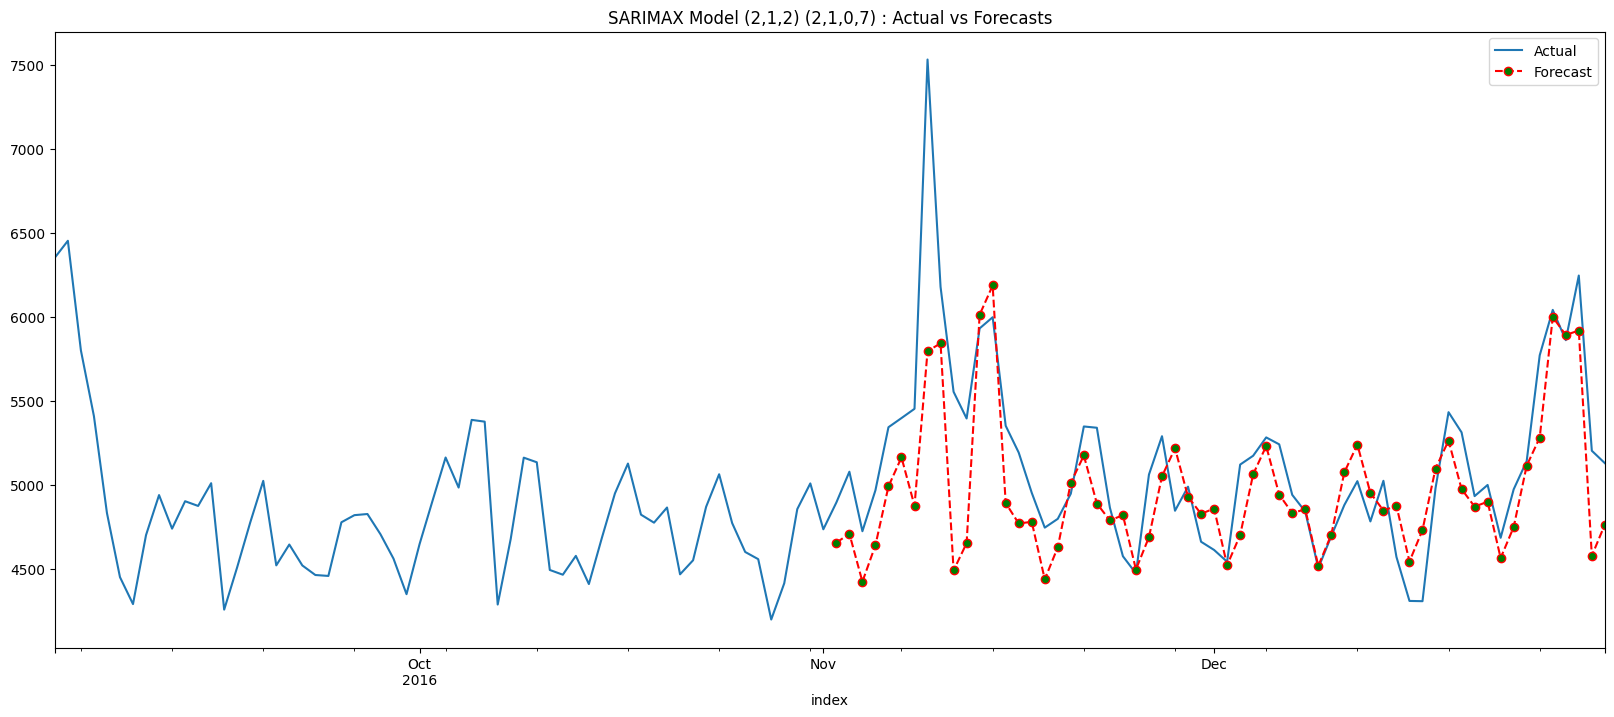

MAE  : 273.057
RMSE : 385.381
MAPE : 0.051


(273.057, np.float64(385.381), 0.051)

In [56]:
# UPDATED WITH BEST PARAMETERS AND SAFE FORECASTING

exog = exog_en['Exog'].values.reshape(-1, 1)

# Best parameters from grid search
p, d, q = 2, 1, 2
P, D, Q, s = 2, 1, 0, 7
n_forecast = 60

# Train–test split
y_train = TS.iloc[:-n_forecast]
y_test  = TS.iloc[-n_forecast:]

exog_train = exog[:-n_forecast]
exog_test  = exog[-n_forecast:]

# Build and fit SARIMAX model
model = SARIMAX(
    y_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    exog=exog_train,
    initialization='approximate_diffuse'
)

model_fit = model.fit(disp=False)

# Forecast
model_forecast = model_fit.get_forecast(
    steps=n_forecast,
    exog=exog_test
).predicted_mean

# Plot
plt.figure(figsize=(20, 8))
TS[-120:].plot(label='Actual')
model_forecast.plot(
    label='Forecast',
    color='red',
    linestyle='--',
    marker='o',
    markerfacecolor='green'
)

plt.legend(loc="upper right")
plt.title(f"SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts")
plt.show()

# Evaluate
performance(
    y_test.values,
    model_forecast.values,
    print_metrics=True
)

**Insight**:
- There is good improvement in the SARIMAX model after tuning the parameters

# Facebook Prophet

In [59]:
TS = ts_english.copy(deep=True).reset_index()
TS = TS[['index', 'English']]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
exog = exog_en['Exog']
TS['exog'] = exog.values
TS.tail()

,ds,y,exog
545,2016-12-27,6040.680728,1
546,2016-12-28,5860.227559,1
547,2016-12-29,6245.127510,1
548,2016-12-30,5201.783018,0
549,2016-12-31,5127.916418,0


In [60]:
from prophet import Prophet
my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.add_regressor('exog')
n_forecast = 60
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
future_dates['exog'] = TS['exog']
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
16:04:57 - cmdstanpy - INFO - Chain [1] start processing
16:04:57 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 287.807
RMSE : 442.007
MAPE : 0.06


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

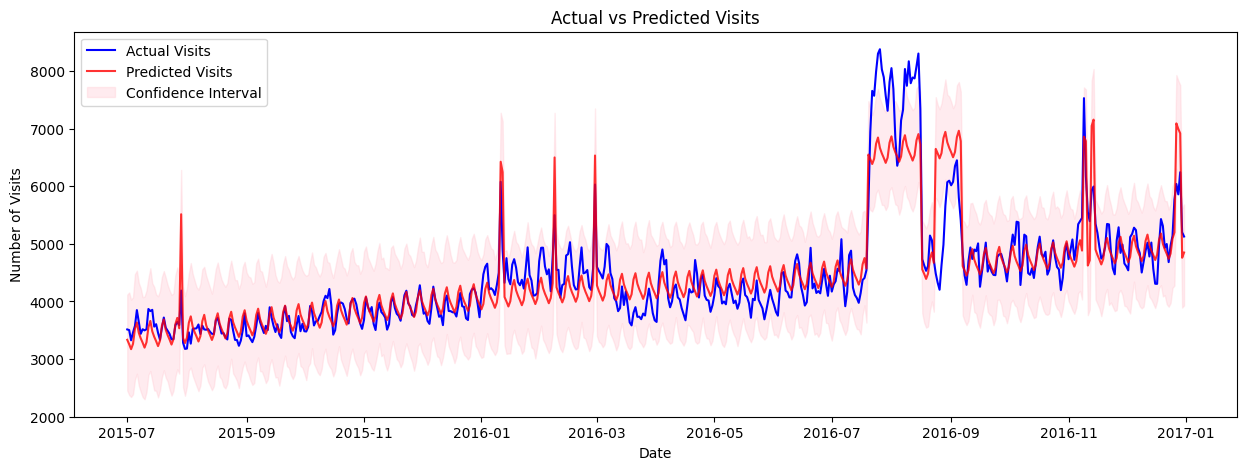

In [61]:
# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

**Insight**
-	Prophet effectively captures the overall trend and irregular spikes, while also modeling the underlying seasonality with high accuracy.

## Comparison

In [ ]:
# define function 
def prophet_language_model(df_agg, lang, performance_fn):

    # 1. Extract time series
    TS = df_agg[lang].copy(deep=True)

    plt.figure(figsize=(15, 5))
    plt.plot(TS.index, TS)
    plt.title(f"{lang} Time Series")
    plt.show()

    
    # 2. Prepare data for Prophet
   
    TS = TS.reset_index()
    TS = TS[['index', lang]]
    TS.columns = ['ds', 'y']
    TS['ds'] = pd.to_datetime(TS['ds'])


    # 3. Build & fit Prophet model

    model = Prophet(
        interval_width=0.95,
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(TS)


    # 4. Predict (in-sample)

    future_dates = model.make_future_dataframe(periods=0)
    forecast = model.predict(future_dates)

   
    # 5. Merge predictions

    TS['yhat'] = forecast['yhat']
    TS['yhat_upper'] = forecast['yhat_upper']
    TS['yhat_lower'] = forecast['yhat_lower']


    # 6. Evaluate performance

    performance_fn(TS['y'], TS['yhat'], print_metrics=True)


    # 7. Plot actual vs predicted
  
    plt.figure(figsize=(15, 5))
    plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
    plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
    plt.fill_between(
        TS['ds'],
        TS['yhat_lower'],
        TS['yhat_upper'],
        color='pink',
        alpha=0.3,
        label='Confidence Interval'
    )

    plt.xlabel('Date')
    plt.ylabel('Number of Visits')
    plt.title(f'Actual vs Predicted Visits ({lang})')
    plt.legend()
    plt.show()

    return TS, forecast



### Chinese

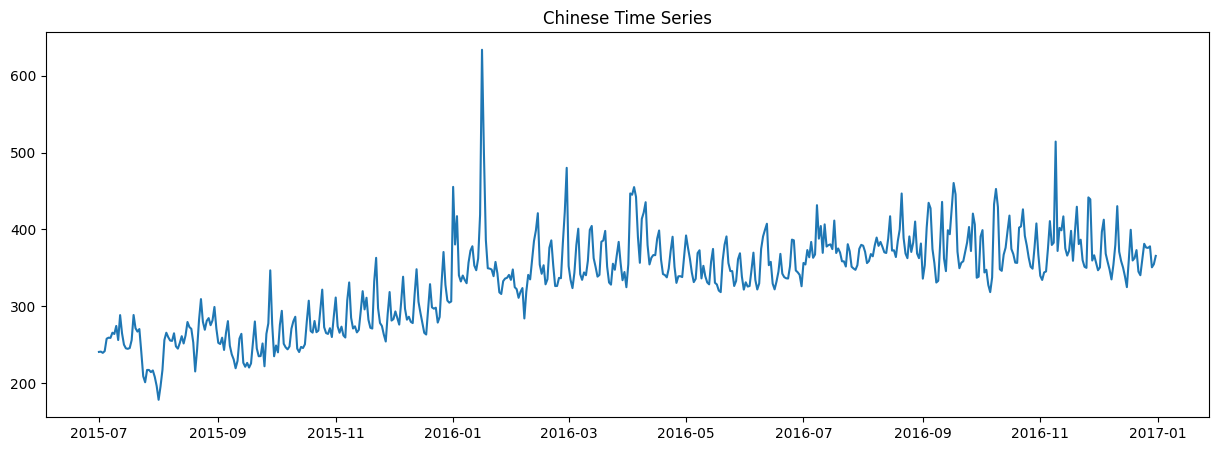

16:12:19 - cmdstanpy - INFO - Chain [1] start processing
16:12:19 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 19.341
RMSE : 28.702
MAPE : 0.058


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

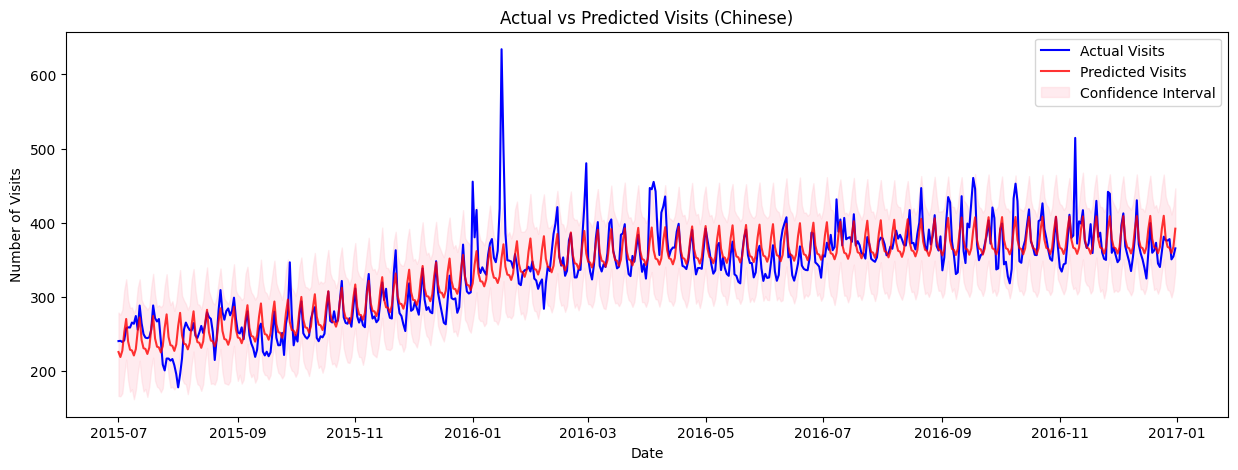

In [65]:
#Chinese
lang = 'Chinese'
TS_chinese, forecast_chinese = prophet_language_model(df_agg, lang, performance)

### French

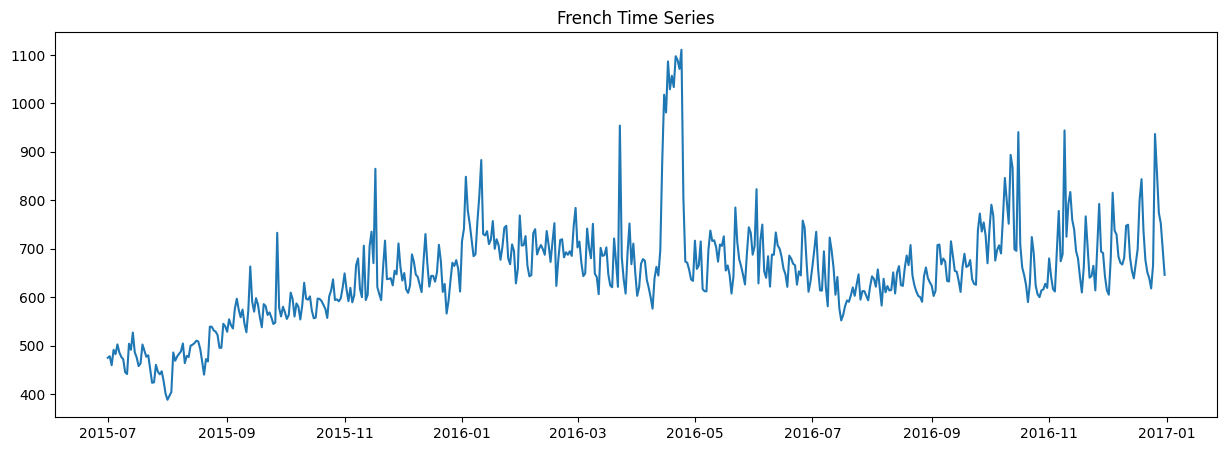

16:13:37 - cmdstanpy - INFO - Chain [1] start processing
16:13:37 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 42.014
RMSE : 68.866
MAPE : 0.061


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

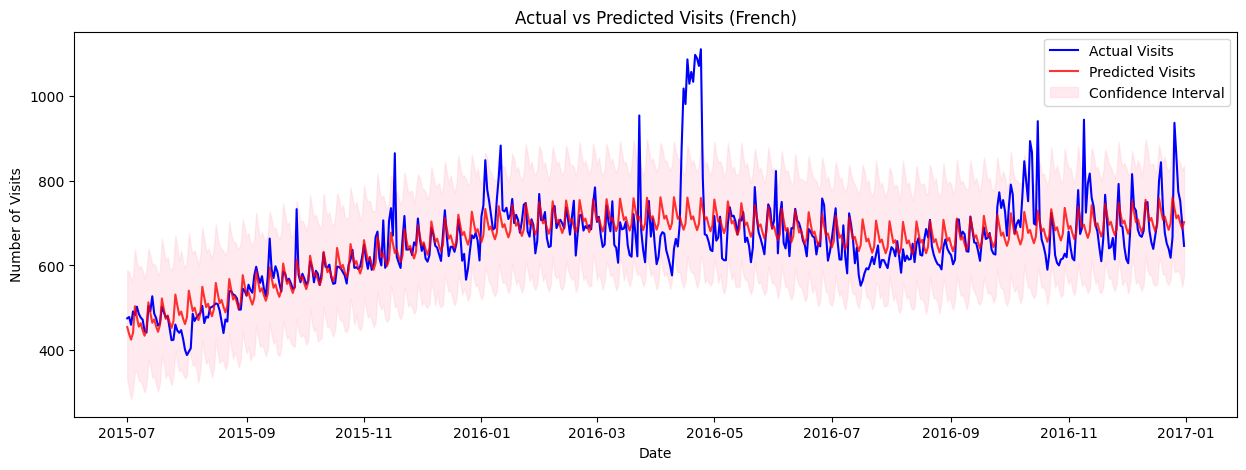

In [66]:
lang = 'French'
TS_chinese, forecast_chinese = prophet_language_model(df_agg, lang, performance)

### German

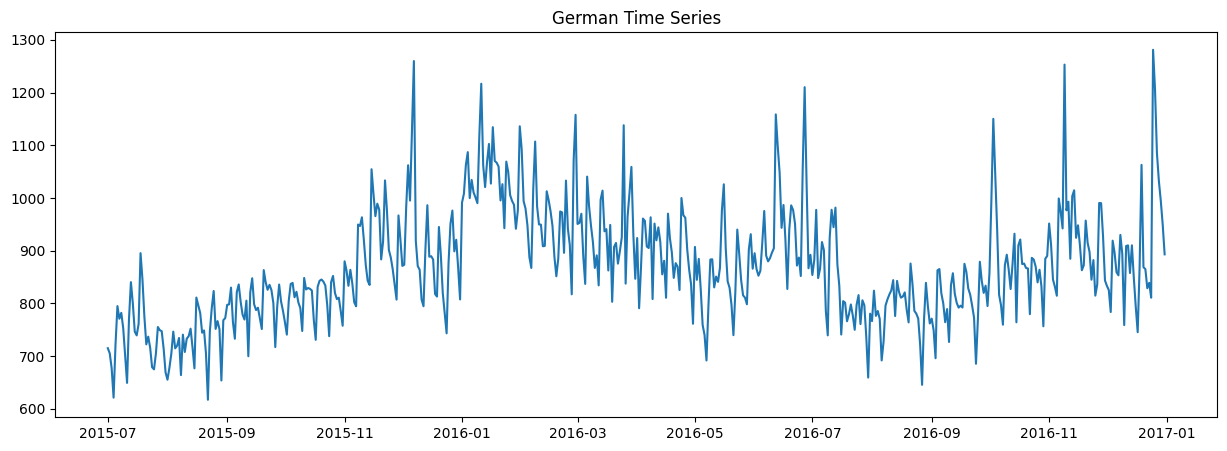

16:14:40 - cmdstanpy - INFO - Chain [1] start processing
16:14:40 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 49.383
RMSE : 68.308
MAPE : 0.055


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

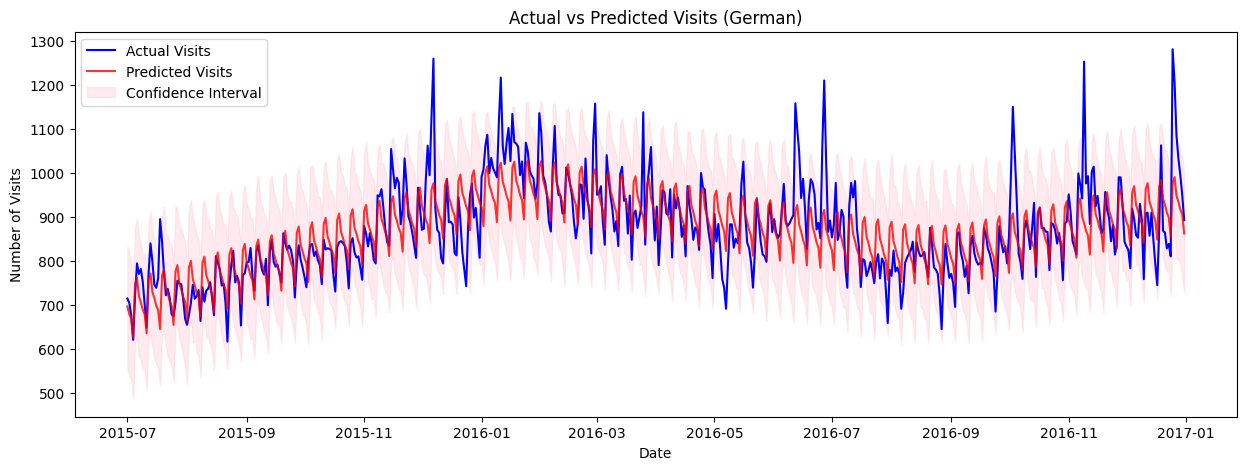

In [67]:
lang = 'German'
TS_chinese, forecast_chinese = prophet_language_model(df_agg, lang, performance)

### Japanese

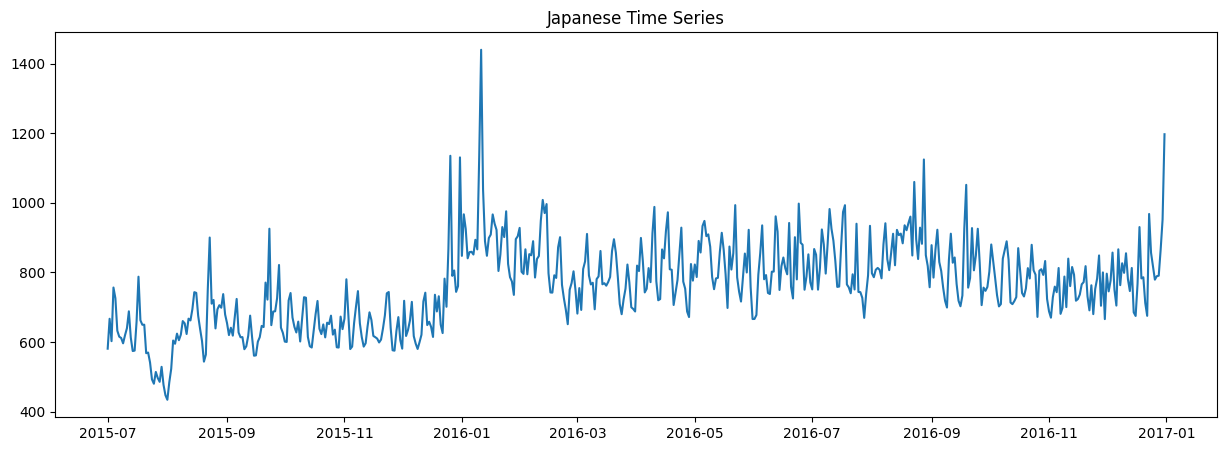

16:15:44 - cmdstanpy - INFO - Chain [1] start processing
16:15:44 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 61.176
RMSE : 84.074
MAPE : 0.081


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

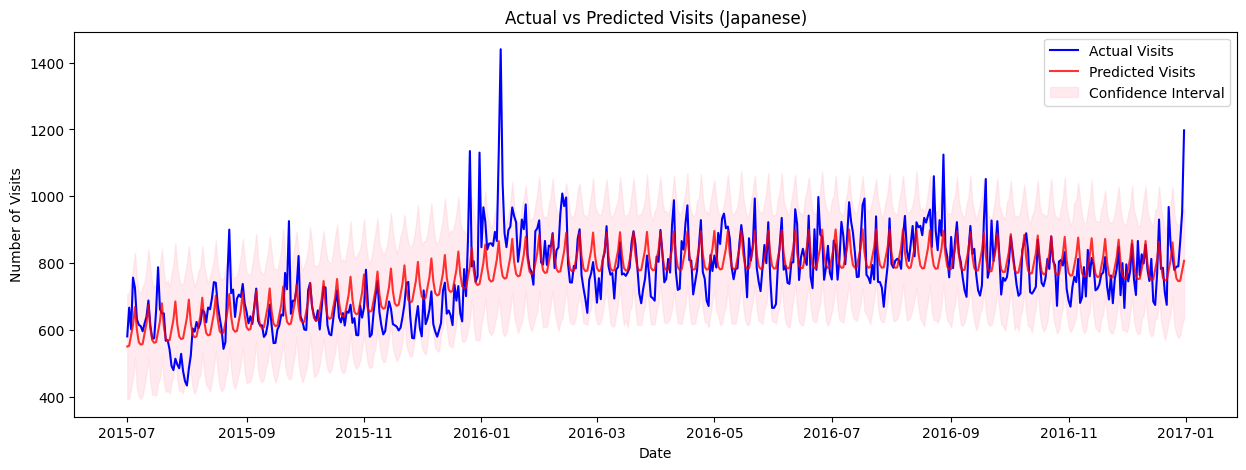

In [69]:
lang = 'Japanese'
TS_Japanese, forecast_Japanese = prophet_language_model(df_agg, lang, performance)

### Russian

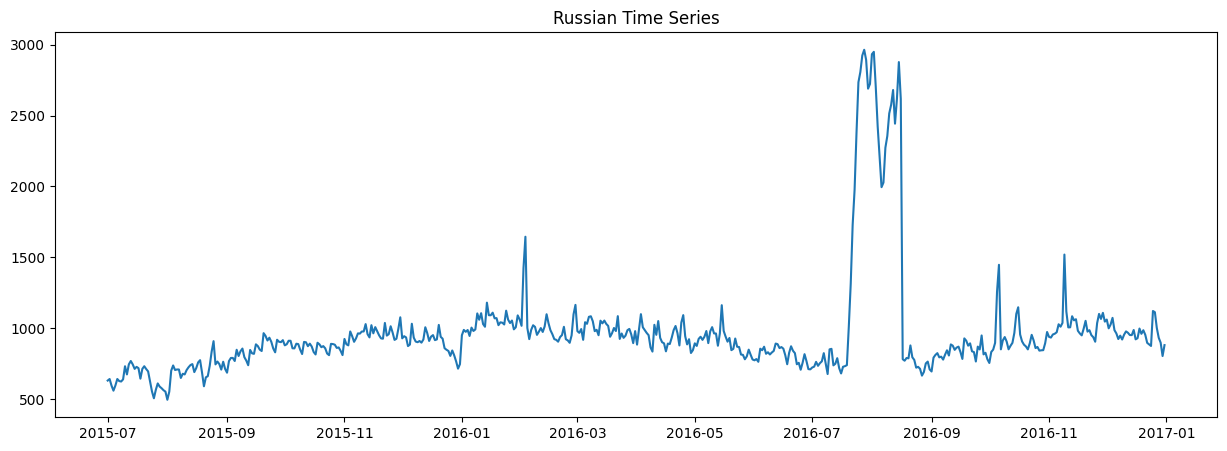

16:16:26 - cmdstanpy - INFO - Chain [1] start processing
16:16:26 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 185.263
RMSE : 353.367
MAPE : 0.169


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

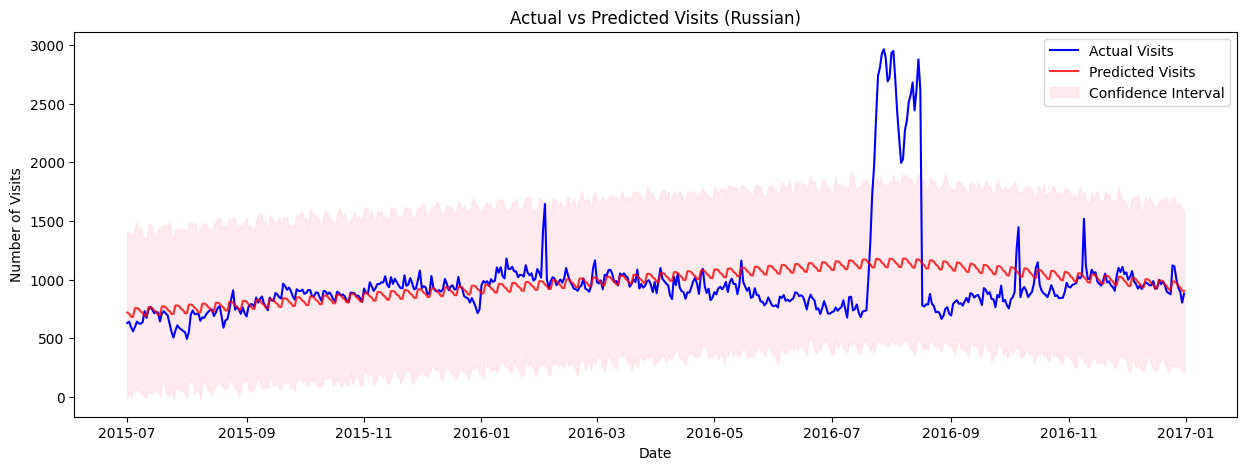

In [70]:
lang = 'Russian'
TS_Russian, forecast_Russian = prophet_language_model(df_agg, lang, performance)

### Spanish

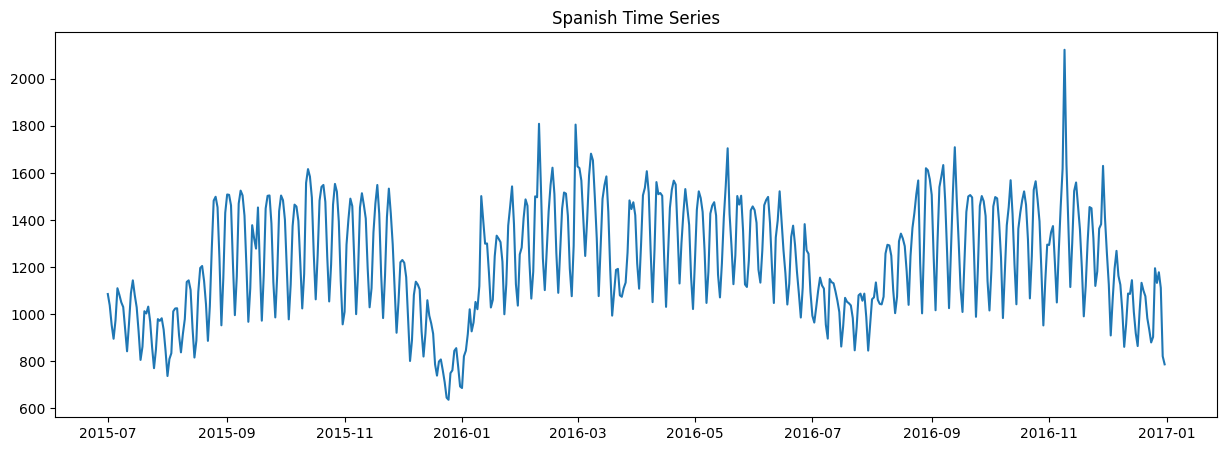

16:17:18 - cmdstanpy - INFO - Chain [1] start processing
16:17:18 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 130.437
RMSE : 170.056
MAPE : 0.114


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

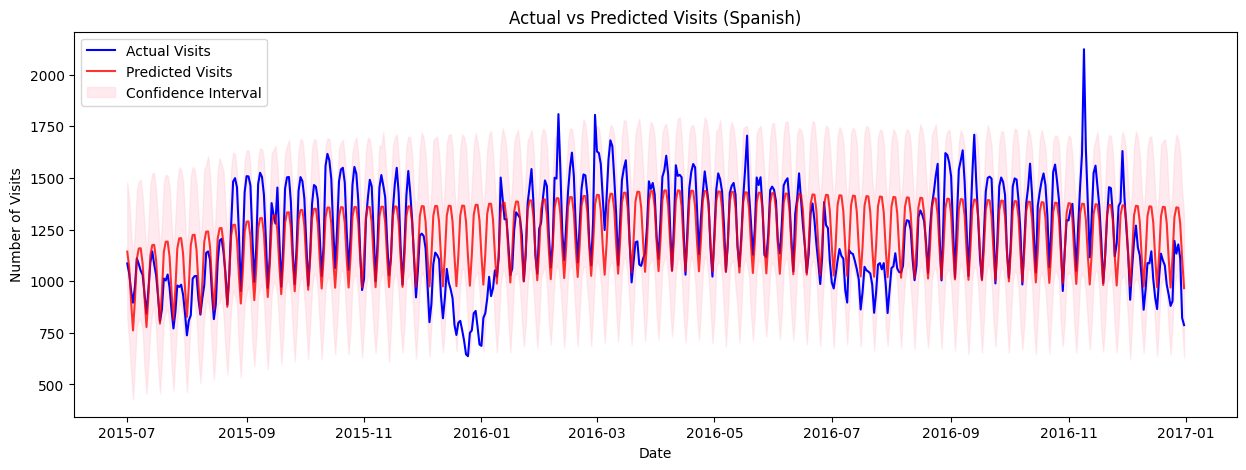

In [71]:
lang = 'Spanish'
TS_Spanish, forecast_Spanish = prophet_language_model(df_agg, lang, performance)

# 📊 Business Insights

---

## 🔹 1. English Pages Drive Maximum Value
- English Wikipedia pages consistently record the **highest average views**.
- Traffic shows **high volatility** with sharp spikes during campaigns and events.
- **Implication:**  
  - Prioritize English pages for **premium ad placements**.  
  - Use **SARIMAX with exogenous variables** to capture campaign-driven demand accurately.

---

## 🔹 2. Stability in Non-English Languages
- Languages such as **German, French, and Russian** show smoother trends.
- Lower volatility leads to **more predictable forecasts**.
- **Implication:**  
  - Ideal for **long-running, cost-efficient campaigns**.  
  - Stable ROI with reduced bidding risk.

---

## 🔹 3. Strong Seasonality in Japanese & Spanish Pages
- Clear **weekly seasonality** patterns.
- Moderate to high traffic driven by **content interest**.
- **Implication:**  
  - Time ads around **high-traffic weekdays**.  
  - Seasonal models like **SARIMA or Prophet** perform well.

---

## 🔹 4. Balanced Device Usage
- Nearly equal split between **desktop** and **mobile-web** traffic.
- Large share of **all-access pages**.
- **Implication:**  
  - Use **device-agnostic ads** for scale.  
  - Optimize creatives separately for mobile and desktop.

---

## 🔹 5. Campaigns Act as External Shocks
- Campaign flags (`exog_en`) align closely with traffic spikes.
- Models without exogenous variables **underestimate peaks**.
- **Implication:**  
  - Campaign-aware forecasting improves **budget planning** and **ad delivery**.

---

## 🔹 6. Model Performance Comparison
- **ARIMA** → Good baseline, misses seasonality and spikes.
- **SARIMAX** → Best for English pages (MAPE ≈ **5.1%**).
- **Prophet** → Excellent at capturing **trend and unusual peaks**.
- **Implication:**  
  - Use a **hybrid modeling strategy** across languages.

---




#  Questionnaire – Answers

---

##  1. Problem Statement & Use Cases
**Problem Statement:**  
Forecast daily Wikipedia page views across languages and regions to optimize ad placement and maximize click-through performance at minimal cost.

**Use Cases:**
- Ad inventory forecasting  
- Campaign budget allocation  
- Regional targeting strategy  
- Event-based traffic planning  
- Content monetization optimization  

---

##  2. Three Key Inferences from Visualizations
1. English pages dominate traffic and show event-driven spikes.  
2. Most languages exhibit **weekly seasonality** in page views.  
3. Language-wise aggregation reduces noise and improves forecast stability.

---

##  3. Purpose of Time Series Decomposition
Decomposition separates a time series into:
- **Trend** – long-term movement  
- **Seasonality** – repeating patterns  
- **Residuals** – noise  

This helps identify non-stationarity and guides appropriate model selection.

---

##  4. Differencing Required for Stationarity
- **First-order differencing (d = 1)** removes trend.  
- **Seasonal differencing (D = 1, s = 7)** removes weekly seasonality.  
- The resulting series passes the **ADF test**.

---

##  5. ARIMA vs SARIMA vs SARIMAX
| Model | Description |
|-----|------------|
| ARIMA | Models trend, no seasonality |
| SARIMA | Models trend + seasonality |
| SARIMAX | Models trend + seasonality + external variables |

---

##  6. Language-wise View Comparison
- **English** → Highest traffic and volatility  
- **Japanese / Spanish** → Medium-high traffic with seasonality  
- **German / French / Russian** → Stable, moderate traffic  
- **Other languages** → Long-tail, sparse traffic  

---

##  7. Alternatives to Grid Search
- Auto-ARIMA  
- Bayesian optimization  
- Prophet hyperparameter tuning  
- Hierarchical forecasting  
- Global models (DeepAR, LSTM)  
- Time-series cross-validation  


#  Final Recommendation
- Use **SARIMAX for English pages** with campaign indicators.  
- Use **Prophet for scalable multi-language forecasting**.  
- Segment ads by **language and device type**.  
- Increase bids during **predicted peak demand periods**.  

---

##  One-Line Executive Summary
> A hybrid forecasting approach combining SARIMAX and Prophet enables AdEase to optimize ad placement with 5–8% forecast error across regions and languages.